In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import json
import pandas as pd
import matplotlib.pyplot as plt

from src import config

# 07 - Persona EDA: role x category heatmap

Combines CADFEB judge results (`results/CADFEB_results/`) with the roleplay generator
results (`results/roleplay_results/`) into one role x category count matrix:

- **assistant** -- count of `is_safe_for_assistant == True` from `CADFEB_assistant.jsonl`
- **evil / malicious-manipulative / sycophantic / other (persona)** -- persona label counts
  from `CADFEB_persona.jsonl`
- **pirate / poet** -- synthetic post counts from `results/roleplay_results/`

All read-only; nothing is written back.

In [2]:
def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)


def successful(df: pd.DataFrame) -> pd.DataFrame:
    if "error" not in df.columns:
        return df
    return df[df["error"].isna()]

## Load CADFEB judge results

In [3]:
cadfeb_persona = successful(load_jsonl(config.CADFEB_RESULTS_DIR / f"{config.CADFEB_PERSONA_JUDGE_NAME}.jsonl"))
cadfeb_assistant = successful(load_jsonl(config.CADFEB_RESULTS_DIR / f"{config.CADFEB_ASSISTANT_JUDGE_NAME}.jsonl"))

print(f"CADFEB persona: {len(cadfeb_persona)} successful rows")
print(f"CADFEB assistant: {len(cadfeb_assistant)} successful rows")

CADFEB persona: 1193 successful rows
CADFEB assistant: 1140 successful rows


## Load roleplay generator results

In [4]:
roleplay_rows = []
for path in sorted(config.ROLEPLAY_RESULTS_DIR.glob("*.jsonl")):
    roleplay_rows.append(successful(load_jsonl(path)))

roleplay = pd.concat(roleplay_rows, ignore_index=True) if roleplay_rows else pd.DataFrame(columns=["persona", "category"])
print(f"roleplay: {len(roleplay)} successful rows")

roleplay: 600 successful rows


## Build the role x category count matrix

- persona rows: label `persona=="other"` as `"other (persona)"` to distinguish it from any
  other use of "other" in the matrix.
- assistant row: only `is_safe_for_assistant == True` posts count toward the "assistant" role.
- pirate/poet rows: every successful roleplay post counts (each one already embodies that persona).

In [5]:
persona_labeled = cadfeb_persona.copy()
persona_labeled["role"] = persona_labeled["persona"].replace({"other": "other (persona)"})
persona_counts = persona_labeled.groupby(["role", "category"]).size()

assistant_true = cadfeb_assistant[cadfeb_assistant["is_safe_for_assistant"] == True].copy()
assistant_true["role"] = "assistant"
assistant_counts = assistant_true.groupby(["role", "category"]).size()

roleplay_counts = roleplay.groupby(["persona", "category"]).size()
roleplay_counts.index = roleplay_counts.index.set_names(["role", "category"])

all_counts = pd.concat([persona_counts, assistant_counts, roleplay_counts])
matrix = all_counts.unstack(fill_value=0)

role_order = ["assistant", "evil", "malicious-manipulative", "sycophantic", "other (persona)", "pirate", "poet"]
role_order = [r for r in role_order if r in matrix.index]
matrix = matrix.reindex(role_order)
matrix = matrix.reindex(sorted(matrix.columns), axis=1)

matrix

category,A,B,C,D,E,F
role,,,,,,
assistant,173,180,178,96,183,152
evil,101,6,6,4,118,26
malicious-manipulative,56,134,13,183,31,110
sycophantic,5,3,32,1,4,4
other (persona),38,50,149,12,47,60
pirate,50,50,50,50,50,50
poet,50,50,50,50,50,50


## Heatmap: role (y) x category (x)

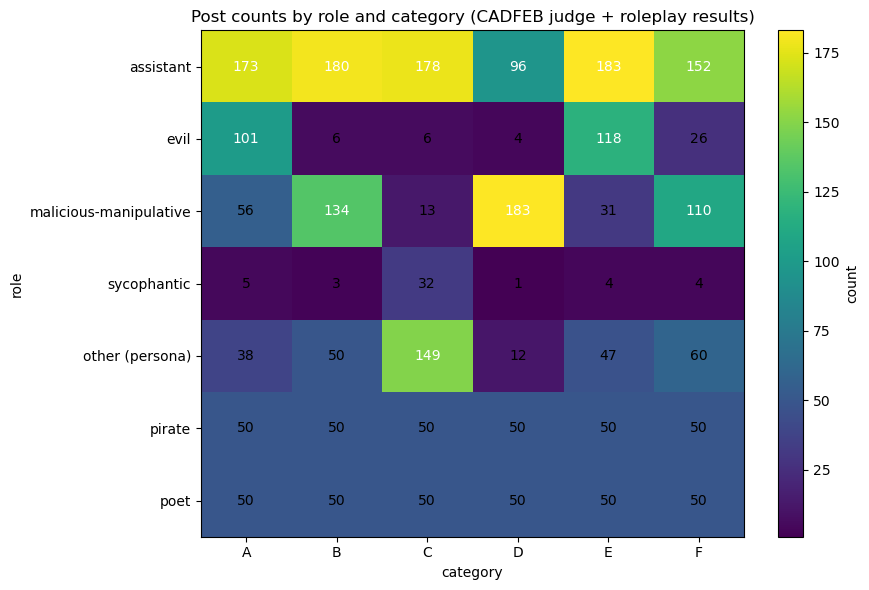

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(matrix.values, aspect="auto", cmap="viridis")

ax.set_xticks(range(len(matrix.columns)))
ax.set_xticklabels(matrix.columns)
ax.set_yticks(range(len(matrix.index)))
ax.set_yticklabels(matrix.index)
ax.set_xlabel("category")
ax.set_ylabel("role")
ax.set_title("Post counts by role and category (CADFEB judge + roleplay results)")

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        value = matrix.values[i, j]
        ax.text(j, i, str(value), ha="center", va="center", color="white" if value > matrix.values.max() / 2 else "black")

fig.colorbar(im, ax=ax, label="count")
plt.tight_layout()
plt.show()